# **Serialización de Modelo**

En este notebook se hará uso de un dataset sobre Aprobación de Préstamos, donde el objetivo es clasificar si el préstamo solicitado se aprueba o no. El dataset se encuentra en Kaggle: https://www.kaggle.com/datasets/anishdevedward/loan-approval-dataset

In [63]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anishdevedward/loan-approval-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-approval-dataset' dataset.
Path to dataset files: /kaggle/input/loan-approval-dataset


In [64]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [65]:
filepath = Path(path) / Path("loan_approval.csv")

data = pd.read_csv(filepath)

data.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


# **Información Básica y Estadisticas**

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


Como se puede ver hay 8 variables, 5 numéricas y 3 categóricas. Una de las categóricas es la objetivo, siendo esta si el préstamo fue aprobado o no.

In [67]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
income,2000.0,90585.977,34487.874907,30053.0,61296.25,90387.5,120099.75,149964.0
credit_score,2000.0,573.946,160.564945,300.0,433.00,576.0,715.00,850.0
loan_amount,2000.0,25308.503,14207.320147,1022.0,12748.75,25661.5,37380.50,49999.0
years_employed,2000.0,20.441,11.777813,0.0,10.00,21.0,31.00,40.0
points,2000.0,56.680,18.638033,10.0,45.00,55.0,70.00,100.0


# **Visualización de Características Numéricas**

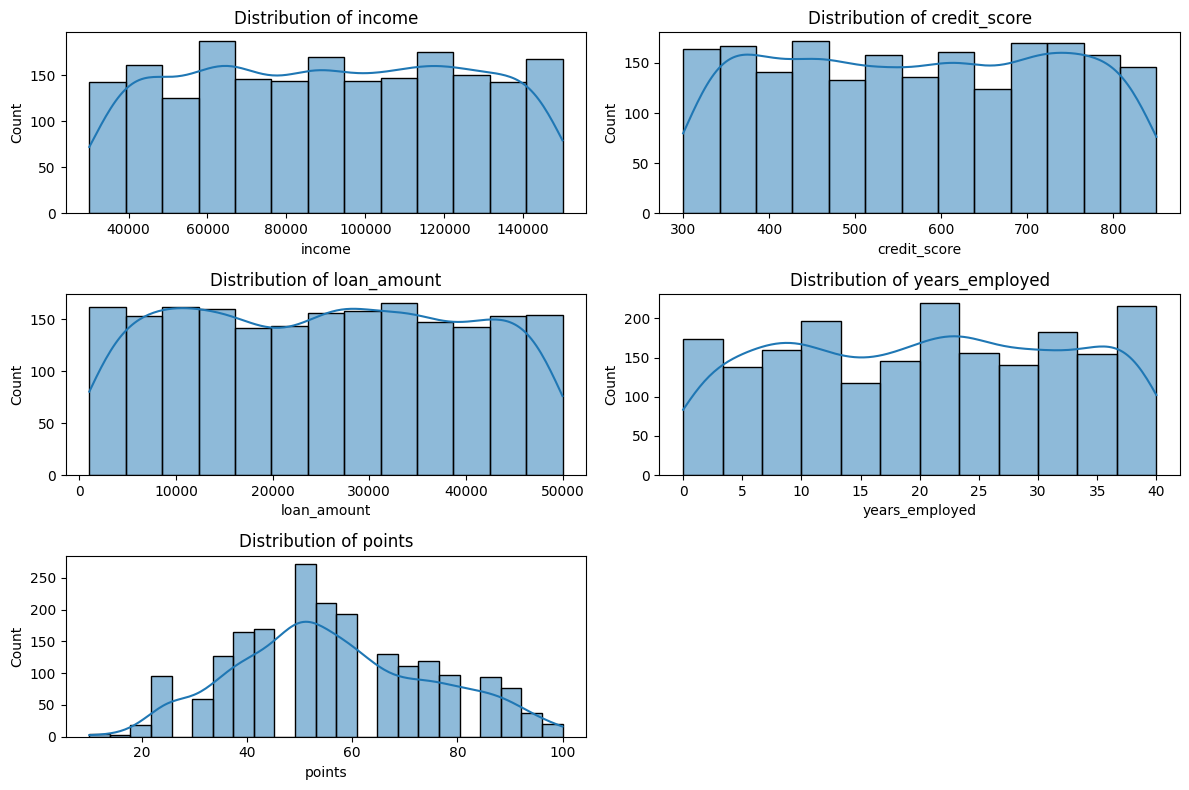

In [68]:
numerical_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

fig, axs = plt.subplots(3, 2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

axs[-1, -1].set_visible(False)

fig.tight_layout()

Para mantener una escala consistente para todas las variables numéricas se les aplicará StandardScaler.

# **Visualización de Características Categóricas**
No se realizó una visualización sobre estas características como Name y City debido a que tiene muchos valores únicos que no influyen dentro del modelo.

# **Distribución de la Característica Objetivo**

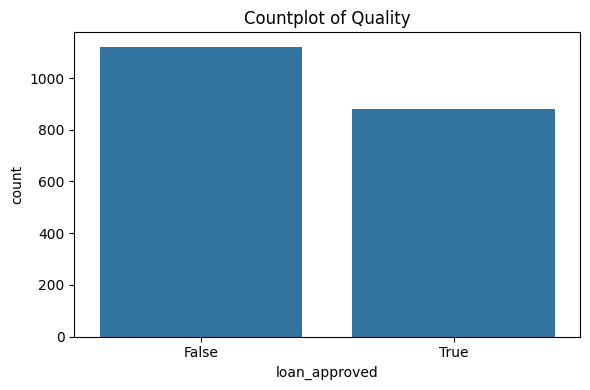

In [69]:
fig = plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='loan_approved')
plt.title('Countplot of Quality')
plt.tight_layout()

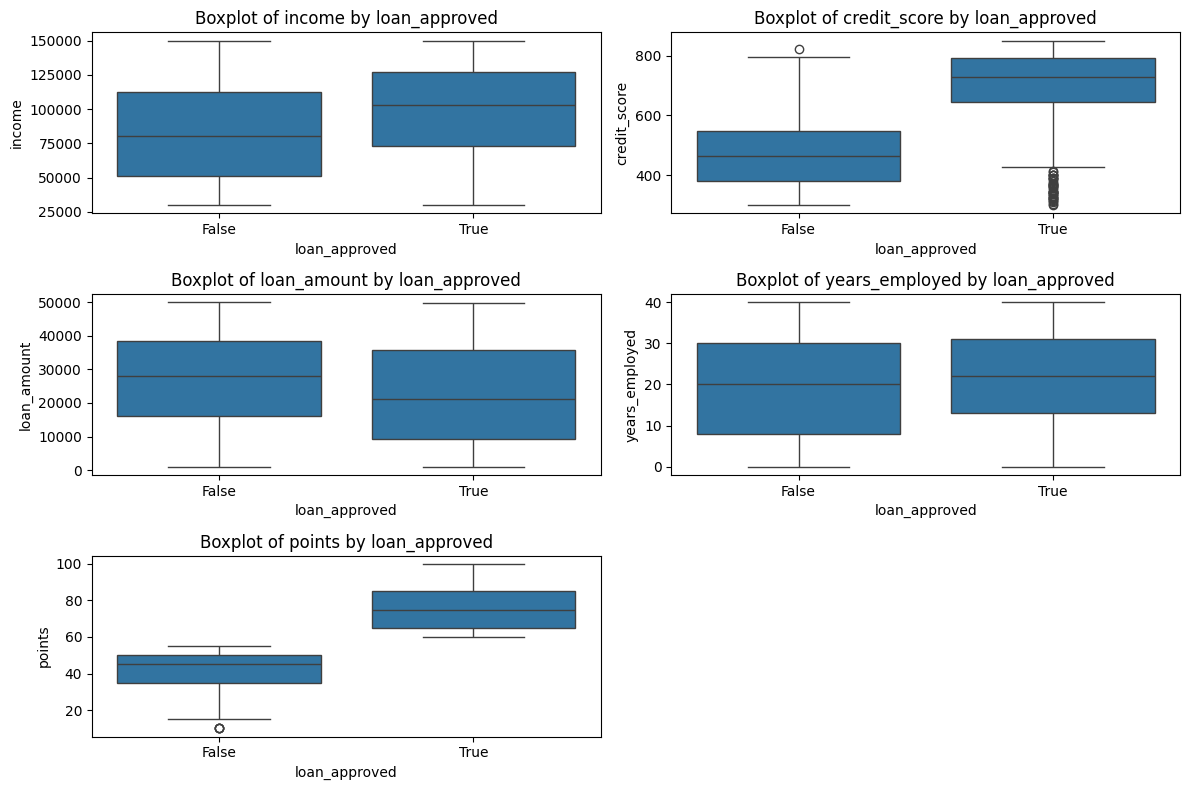

In [70]:
fig, axs = plt.subplots(3, 2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.boxplot(data=data, x='loan_approved', y=col, ax=ax)
    ax.set_title(f'Boxplot of {col} by loan_approved')

axs[-1, -1].set_visible(False)

fig.tight_layout()

De los boxplot se puede obtener que para aprobar el préstamo se tienen mayores valores en income,  más años de empleado y especialmente valores más altos en credit score.

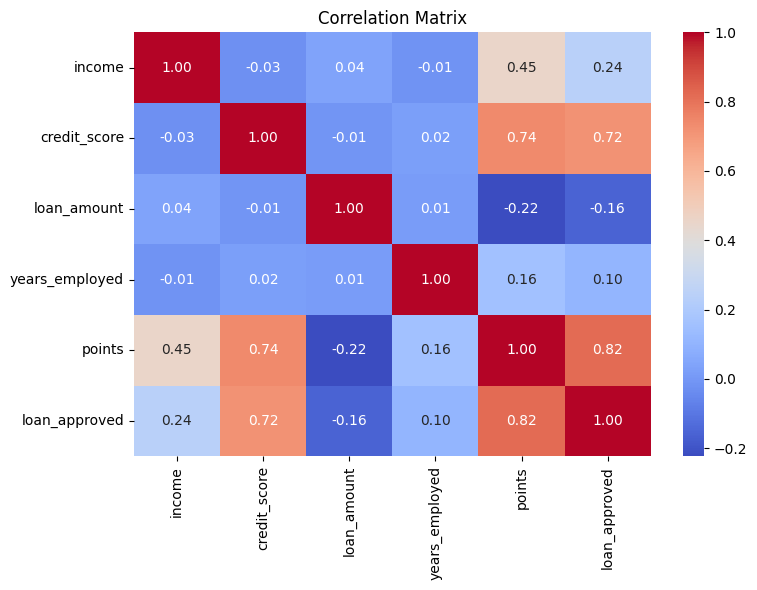

In [71]:
corr_matrix = data[['income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved']].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

En la matriz de correlación se ve la relación entre variables, points se descartará para el modelo debido a que en el modelo se menciona que es un valor computado que probablemente surja de una operación entre variables y puede resultar en valores sesgados.

In [72]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('num', StandardScaler(),
             ['income', 'credit_score', 'loan_amount', 'years_employed']),
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )
)

Aquí se realiza las transformaciones a los datos para crear el pipeline de preprocesamiento. Aplicando standard scaling a las variables numéricas y que no destaquen los valores más grandes. Loan_approved se convierte a entero para tomar el 0 o 1 para no aprobado y aprobado.

In [73]:
numerical_cols = ['income', 'credit_score', 'loan_amount', 'years_employed']
x = data[numerical_cols]
y = data['loan_approved'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

El dataset se divide en entrenamiento y test, 80% entrenamiento, 20% test.

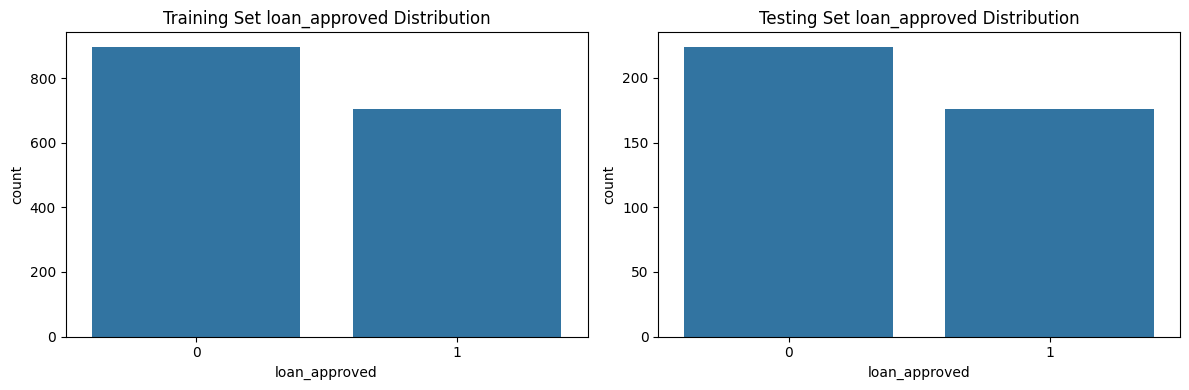

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Training Set loan_approved Distribution')
sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Testing Set loan_approved Distribution')
fig.tight_layout()

In [75]:
x_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
x_train_processed

array([[-0.17342933,  0.49019042,  0.03478074, -1.15397086],
       [-0.22960205,  0.7959233 , -1.22829888,  1.40035707],
       [ 0.4646404 , -0.56427605,  0.36246017,  1.48550133],
       ...,
       [ 0.17143626,  1.20772677, -1.41369924, -1.15397086],
       [ 0.10030354, -1.03847398,  0.60573197,  0.80434722],
       [ 0.1578442 ,  0.0721475 ,  1.10109744, -1.23911512]])

In [76]:
x_test_processed = preprocessing_pipeline.transform(X_test)
x_test_processed

array([[ 0.2652709 ,  0.50266931,  1.53485099, -0.13223969],
       [-0.82168583, -0.67658608,  0.09265219,  0.3786259 ],
       [-1.57937726,  1.64448803, -0.69390547, -0.8133938 ],
       ...,
       [ 0.06834621,  1.47602297, -1.29315725,  0.03804884],
       [ 1.08681878, -1.36916465,  1.48693061,  1.05978001],
       [-0.11099903, -0.58299439,  0.11904721,  1.48550133]])

# **Construir Modelo de Clasificación**

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

Se hace un pipeline para incluir el preprocesamiento y el modelo Random Forest.

In [78]:
loan_classification_model = make_pipeline(
    preprocessing_pipeline,
    RandomForestClassifier(max_depth=None, min_samples_split=5, n_estimators=300)
)
loan_classification_model

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['income',
                                                                    'credit_score',
                                                                    'loan_amount',
                                                                    'years_employed'])],
                                                    verbose_feature_names_out=False))])),
                ('randomforestclassifier',
                 RandomForestClassifier(min_samples_split=5,
                                        n_estimators=300))])

In [79]:
loan_classification_model.fit(X_train, y_train)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['income',
                                                                    'credit_score',
                                                                    'loan_amount',
                                                                    'years_employed'])],
                                                    verbose_feature_names_out=False))])),
                ('randomforestclassifier',
                 RandomForestClassifier(min_samples_split=5,
                                        n_estimators=300))])

In [80]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
best_model_rf = grid_rf.best_estimator_

Mejores parámetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


Se escogió Recall ya que se quieren reducir los falos negativos, ya que un falso negativo es negarle el servicio a un cliente que si puede pagarlo, lo que sería perder un cliente, algo que no se quiere hacer.

In [81]:
grid_rf.best_score_

np.float64(0.9814893617021276)

En esta sección se evalúa el rendimiento del modelo de Random Forest en su set de entrenamiento y de test.

In [82]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def classification_evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}

rf_train_metrics = classification_evaluate_model(best_model_rf, X_train, y_train)
rf_test_metrics = classification_evaluate_model(best_model_rf, X_test, y_test)

metrics_data = {
    "Random Forest (Train)": rf_train_metrics,
    "Random Forest (Test)": rf_test_metrics,
}

metrics_df = pd.DataFrame(metrics_data).T
print("Rendimiento del Modelo Random Forest:")
print(metrics_df)

Rendimiento del Modelo Random Forest:
                       Accuracy  Precision    Recall  F1-Score
Random Forest (Train)  0.999375   0.998580  1.000000  0.999289
Random Forest (Test)   0.987500   0.988571  0.982955  0.985755


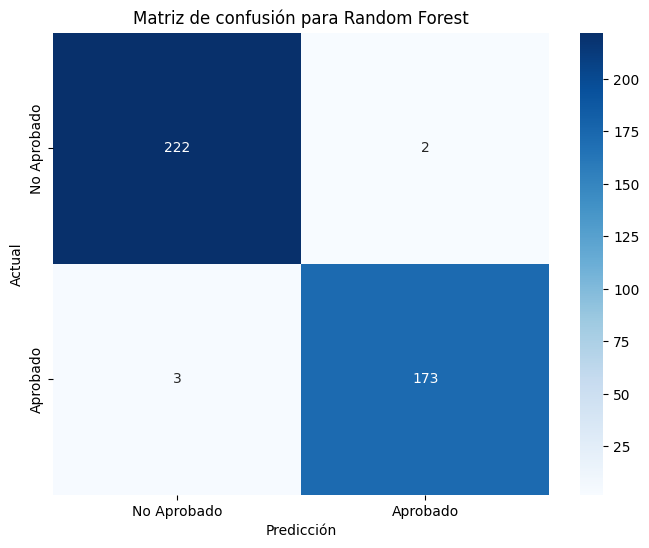


Classification Report para Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       224
           1       0.99      0.98      0.99       176

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [83]:
y_pred_best = best_model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Aprobado", "Aprobado"],
            yticklabels=["No Aprobado", "Aprobado"])
plt.title(f"Matriz de confusión para Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Actual")
plt.show()

print(f"\nClassification Report para Random Forest:")
print(classification_report(y_test, y_pred_best))

# **Seralizar y Exportar Modelo**

Aquí se utiliza joblib para serializar el modelo que tiene el pipeline de preprocesamiento junto al pipeline del modelo de Random Forest.

In [84]:
import joblib

joblib.dump(loan_classification_model, "loan_model.joblib")

['loan_model.joblib']

In [85]:
from google.colab import files

files.download("loan_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusión**
En conclusión, la serialización es un tema importante debido a que permite utilizar modelos ya entrenados donde se requiera, no es necesario volver a entrenar el modelo cada vez que se realice una aplicación. Además de ser fundamental cuando se quiera utilzar un modelo en un entorno de producción. En este caso, el modelo que se entreno ahora puede recibir datos relevantes y con eso realizar una clasificación o en otros modelos cualquier otra tarea que tenga que realizar, evitando que se quede atrapado en un solo entorno para su uso.